In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, log_loss
from sklearn.linear_model import SGDClassifier
from sklearn.exceptions import ConvergenceWarning
import warnings

In [69]:
import sys
import importlib

# --- FIX: AUTORELOAD FOR JUPYTER ---
# These lines ensure that when you save changes to logistic_regression.py, 
# the notebook will automatically reload the new code.
%load_ext autoreload
%autoreload 2
# -----------------------------------

# Now importing DH_OBJ from the logistic_regression package
try:
    # 1. Check if the module is already loaded (cached)
    if 'logistic_regression' in sys.modules:
        print("Module 'logistic_regression' found in cache. Forcing reload...")
        importlib.reload(sys.modules['logistic_regression'])
    elif 'utils' in sys.modules:
        print("Module 'utils' found in cache. Forcing reload...")
        importlib.reload(sys.modules['utils'])
    
    # 2. Perform the import (this will use the reloaded or new version)
    from logistic_regression import LogisticRegression_lr
    import utils as ut
except ImportError as e:
    print(f"\n[ERROR] Import failed. Ensure your 'logistic_regression' folder and 'logistic_regression.py' are correctly structured.")
    print(f"Details: {e}")
    sys.exit(1)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Module 'logistic_regression' found in cache. Forcing reload...


In [70]:
# Set styles and seeds for reproducibility
plt.style.use('seaborn-v0_8')
sns.set_palette(sns.color_palette())
np.random.seed(42)

# Suppress ConvergenceWarning
warnings.filterwarnings('ignore', category=ConvergenceWarning)

# Suppress FutureWarning for multi_class (since it's deprecated and defaults to multinomial)
warnings.filterwarnings('ignore', category=FutureWarning)

In [71]:
# 1. Load and prepare data
df = pd.read_excel('../data/Dry_Bean_Dataset.xlsx', sheet_name='Dry_Beans_Dataset')
X = df.iloc[:, 0:16].values
y = df['Class'].values

# desired order
labels_desired_order = ['SEKER', 'BARBUNYA', 'BOMBAY', 'CALI', 'HOROZ', 'SIRA', 'DERMASON']

# Encode labels (7 classes)
label_encoder_full = LabelEncoder()
y_encoded = label_encoder_full.fit_transform(y)
num_classes = len(label_encoder_full.classes_)

# Split data: 70% train, 15% val, 15% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_encoded, test_size=0.33, random_state=42, stratify=y_encoded
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Hyperparameters
alpha_values = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]  # Regularization strength (alpha = 1/C)
n_epochs = 100  # Number of epochs for training

In [72]:
# 4. Hyperparameter regularization (tune alpha for regularization)
print('\nHyperparameter Tuning for Regularization (alpha):')
reg_results = {}

for alpha in alpha_values:
    print(f'Training with alpha={alpha}')
    model = SGDClassifier(loss='log_loss', penalty='l2', alpha=alpha, learning_rate='optimal', 
                          max_iter=n_epochs, random_state=42, tol=1e-4)
    model.fit(X_train_scaled, y_train)
    
    # Evaluate on validation set
    y_val_pred = model.predict(X_val_scaled)
    val_acc = accuracy_score(y_val, y_val_pred)
    reg_results[alpha] = val_acc
    print(f'alpha {alpha}: Validation Accuracy {val_acc:.4f}')

# Select best alpha (highest regularization is highest alpha, but based on acc)
best_alpha = max(reg_results, key=reg_results.get)
print(f'Best alpha: {best_alpha} with Val Acc: {reg_results[best_alpha]:.4f}')


Hyperparameter Tuning for Regularization (alpha):
Training with alpha=0.001
alpha 0.001: Validation Accuracy 0.9181
Training with alpha=0.01
alpha 0.01: Validation Accuracy 0.9029
Training with alpha=0.1
alpha 0.1: Validation Accuracy 0.8571
Training with alpha=1.0
alpha 1.0: Validation Accuracy 0.6020
Training with alpha=10.0
alpha 10.0: Validation Accuracy 0.3891
Training with alpha=100.0
alpha 100.0: Validation Accuracy 0.3842
Best alpha: 0.001 with Val Acc: 0.9181


In [73]:
# 3. Train the model with best alpha, calculate cost, and plot it
print('\nTraining with best alpha and plotting losses:')
model = SGDClassifier(loss='log_loss', penalty='l2', alpha=best_alpha, learning_rate='optimal', 
                      max_iter=1, random_state=42, tol=None)  # max_iter=1 for partial_fit simulation

classes_ = np.unique(y_train)
train_losses = []
val_losses = []

for epoch in range(n_epochs):
    model.partial_fit(X_train_scaled, y_train, classes=classes_)
    
    # Compute train loss
    y_train_proba = model.predict_proba(X_train_scaled)
    train_loss = log_loss(y_train, y_train_proba)
    train_losses.append(train_loss)
    
    # Compute val loss
    y_val_proba = model.predict_proba(X_val_scaled)
    val_loss = log_loss(y_val, y_val_proba)
    val_losses.append(val_loss)
    
    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1}/{n_epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}')


Training with best alpha and plotting losses:
Epoch 10/100, Train Loss: 0.3297, Val Loss: 0.3102
Epoch 20/100, Train Loss: 0.3243, Val Loss: 0.3054
Epoch 30/100, Train Loss: 0.3229, Val Loss: 0.3041
Epoch 40/100, Train Loss: 0.3226, Val Loss: 0.3038
Epoch 50/100, Train Loss: 0.3225, Val Loss: 0.3038
Epoch 60/100, Train Loss: 0.3226, Val Loss: 0.3039
Epoch 70/100, Train Loss: 0.3228, Val Loss: 0.3041
Epoch 80/100, Train Loss: 0.3229, Val Loss: 0.3043
Epoch 90/100, Train Loss: 0.3231, Val Loss: 0.3044
Epoch 100/100, Train Loss: 0.3232, Val Loss: 0.3046


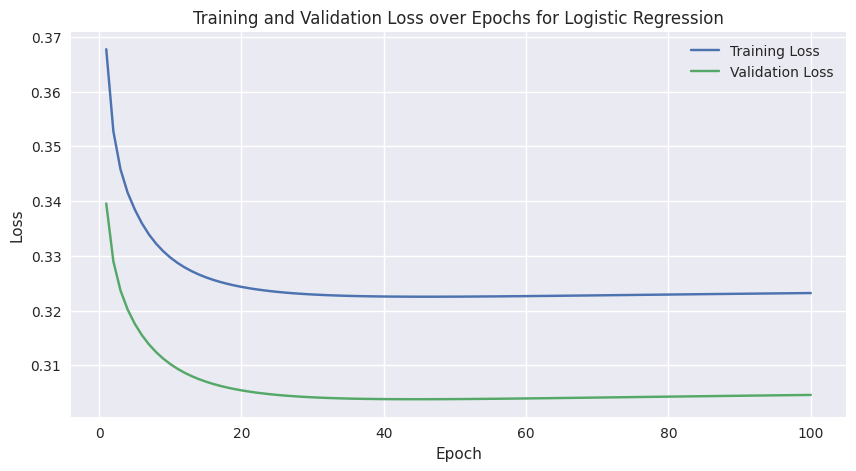

In [74]:
# Plot training and validation cost (loss)
plt.figure(figsize=(10, 5))
plt.plot(range(1, n_epochs + 1), train_losses, label='Training Loss')
plt.plot(range(1, n_epochs + 1), val_losses, label='Validation Loss')
plt.title('Training and Validation Loss over Epochs for Logistic Regression')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [75]:
# Retrain fully with best alpha for evaluation
model = SGDClassifier(loss='log_loss', penalty='l2', alpha=best_alpha, learning_rate='optimal', 
                      max_iter=n_epochs, random_state=42, tol=1e-4)
model.fit(X_train_scaled, y_train)

,loss,'log_loss'
,penalty,'l2'
,alpha,0.001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,100
,tol,0.0001
,shuffle,True
,verbose,0
,epsilon,0.1
,n_jobs,None


In [76]:
# 5. Evaluate accuracy for different number of iterations (epochs)
# (Using the losses loop above, we can evaluate acc at certain points)
print('\nValidation Accuracy at Different Epochs:')
# To simulate, retrain incrementally and check acc
iter_values = [1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000]
iter_val_accuracies = []
iter_test_accuracies = []

temp_model = SGDClassifier(loss='log_loss', penalty='l2', alpha=best_alpha, learning_rate='optimal', 
                           max_iter=1, random_state=42, tol=None)

for epoch in range(max(iter_values)):
    temp_model.partial_fit(X_train_scaled, y_train, classes=classes_)
    if epoch + 1 in iter_values:
        y_val_pred = temp_model.predict(X_val_scaled)
        val_acc = accuracy_score(y_val, y_val_pred)
        iter_val_accuracies.append(val_acc)
        y_test_pred = temp_model.predict(X_test_scaled)
        test_acc = accuracy_score(y_test, y_test_pred)
        iter_test_accuracies.append(test_acc)
        print(f'At epoch {epoch+1}: {val_acc:.4f} {test_acc:.4f}')


Validation Accuracy at Different Epochs:
At epoch 1000: 0.9181 0.9043
At epoch 2000: 0.9181 0.9043
At epoch 3000: 0.9181 0.9043
At epoch 4000: 0.9181 0.9043
At epoch 5000: 0.9181 0.9043
At epoch 6000: 0.9181 0.9043
At epoch 7000: 0.9181 0.9043
At epoch 8000: 0.9181 0.9043
At epoch 9000: 0.9181 0.9043
At epoch 10000: 0.9181 0.9043


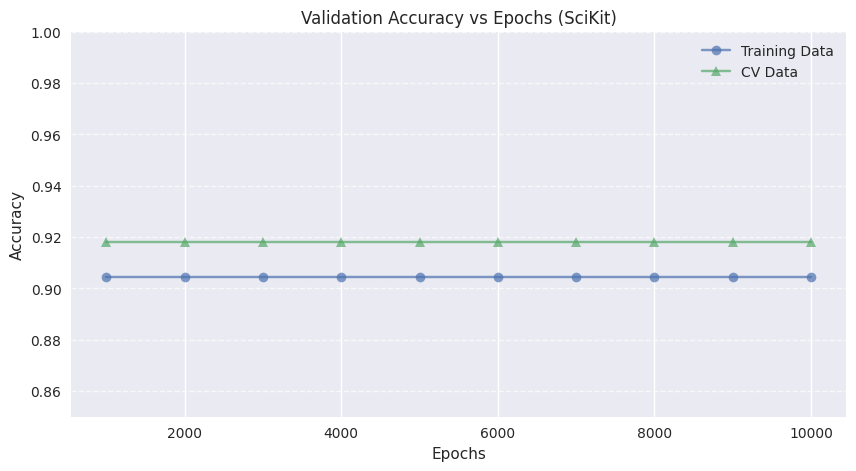


Final Test Accuracy: 0.9074


In [77]:
# Plot accuracies vs epochs (limited to iter_values)
plt.figure(figsize=(10, 5))
plt.plot(iter_values, iter_test_accuracies, label='Training Data', marker='o', alpha=0.7)
plt.plot(iter_values, iter_val_accuracies, label='CV Data', marker='^', alpha=0.7)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.title('Validation Accuracy vs Epochs (SciKit)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.ylim(0.85, 1)
plt.legend()
plt.show()

# Final test accuracy
y_test_pred = model.predict(X_test_scaled)
test_acc = accuracy_score(y_test, y_test_pred)
print(f'\nFinal Test Accuracy: {test_acc:.4f}')

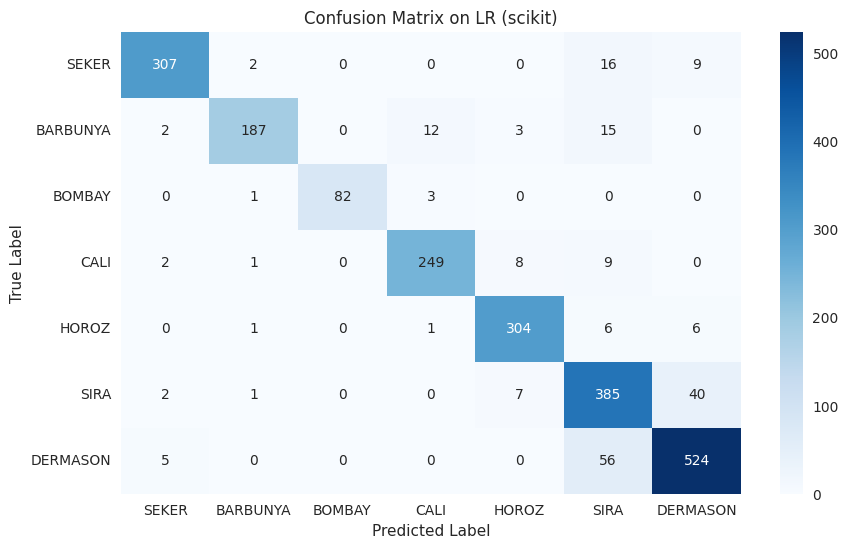

In [78]:
# 6. Plot confusion matrix
cm = confusion_matrix(y_test, y_test_pred, labels=label_encoder_full.transform(labels_desired_order))
conf_df = pd.DataFrame(
    cm,
    index=labels_desired_order, 
    columns=labels_desired_order
)
plt.figure(figsize=(10, 6))
sns.heatmap(conf_df, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels_desired_order,
            yticklabels=labels_desired_order)
plt.title('Confusion Matrix on LR (scikit)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [79]:
# 7. Classification Report
print("\n--- Classification Test Report ---")
# This provides metrics for each of your 7 classes
report = classification_report(y_test, y_test_pred, labels=labels_desired_order, output_dict=True)
ut.classification_report_to_file(report, "lr_lab")

print(classification_report(y_test, y_test_pred, target_names=labels_desired_order))


--- Classification Test Report ---
Metrics saved to 'classification_report/lr_lab.json'
              precision    recall  f1-score   support

       SEKER       0.97      0.85      0.91       219
    BARBUNYA       1.00      0.95      0.98        86
      BOMBAY       0.94      0.93      0.93       269
        CALI       0.91      0.90      0.90       585
       HOROZ       0.94      0.96      0.95       318
        SIRA       0.97      0.92      0.94       334
    DERMASON       0.79      0.89      0.84       435

    accuracy                           0.91      2246
   macro avg       0.93      0.91      0.92      2246
weighted avg       0.91      0.91      0.91      2246



/mnt/d/Uni/ML/dry-bean-classification/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/mnt/d/Uni/ML/dry-bean-classification/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/mnt/d/Uni/ML/dry-bean-classification/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(aver